## Data Loading

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

data_path = Path(r"E:\Jupyter Notebook file\531\Project\ipums_sample.csv")

df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df

Shape: (188419, 30)

Columns:
['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'PERNUM', 'NHISPID', 'HHX', 'SAMPWEIGHT', 'LONGWEIGHT', 'PARTWEIGHT', 'ASTATFLG', 'CSTATFLG', 'RACENEW', 'HISPETH', 'USBORN', 'CITIZEN', 'EDUC', 'MAXEDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY', 'DIABTYPE', 'INSULIN', 'DIAPILLS', 'DIAGLP', 'DIAYRSAGO', 'DIAPRE']


,YEAR,SERIAL,STRATA,PSU,NHISHID,PERNUM,NHISPID,HHX,SAMPWEIGHT,LONGWEIGHT,...,USUALPL,YSKIMPMEDYR,YSKIPMEDYR,HIUNABLEPAY,DIABTYPE,INSULIN,DIAPILLS,DIAGLP,DIAYRSAGO,DIAPRE
0,2020,1,150,25,0002020H000002,1,0002020H00000210,H000002,5946.002,17605.50,...,2,1,1,0,0,0,0,NaN,96,1
1,2020,2,111,10,0002020H000003,1,0002020H00000310,H000003,6288.726,0.00,...,3,1,1,0,0,0,0,NaN,96,1
2,2020,3,133,3,0002020H000004,1,0002020H00000410,H000004,6083.271,0.00,...,2,1,1,0,0,0,0,NaN,96,1
3,2020,4,139,45,0002020H000007,1,0002020H00000710,H000007,11306.962,0.00,...,2,1,1,0,3,1,2,NaN,3,2
4,2020,5,130,21,0002020H000009,1,0002020H00000910,H000009,6471.818,19317.18,...,2,1,1,0,0,1,1,NaN,96,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188414,2024,33913,135,25,0002024H080023,1,0002024H08002310,H080023,9778.000,NaN,...,2,1,1,0,0,1,1,1.0,96,2
188415,2024,33914,116,19,0002024H080026,1,0002024H08002610,H080026,28585.000,NaN,...,2,1,1,0,0,0,0,0.0,96,1
188416,2024,33915,119,6,0002024H080027,1,0002024H08002710,H080027,10140.000,NaN,...,2,1,1,0,0,0,0,0.0,96,1
188417,2024,33916,107,36,0002024H080034,1,0002024H08003410,H080034,8316.000,NaN,...,3,1,1,0,0,0,0,0.0,96,1


## Data Inspection

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData info:")
df.info()

selected_features = [
    "YEAR", "USBORN", "CITIZEN", "EDUC", "MAXEDUC",
    "SCHOOLNOW", "USUALPL", "YSKIMPMEDYR",
    "YSKIPMEDYR", "HIUNABLEPAY"
]

missing_cols = [col for col in selected_features if col not in df.columns]
print("\nMissing columns from selected_features:", missing_cols)

Shape: (188419, 30)

Columns:
['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'PERNUM', 'NHISPID', 'HHX', 'SAMPWEIGHT', 'LONGWEIGHT', 'PARTWEIGHT', 'ASTATFLG', 'CSTATFLG', 'RACENEW', 'HISPETH', 'USBORN', 'CITIZEN', 'EDUC', 'MAXEDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY', 'DIABTYPE', 'INSULIN', 'DIAPILLS', 'DIAGLP', 'DIAYRSAGO', 'DIAPRE']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188419 entries, 0 to 188418
Data columns (total 30 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   YEAR         188419 non-null  int64  
 1   SERIAL       188419 non-null  int64  
 2   STRATA       188419 non-null  int64  
 3   PSU          188419 non-null  int64  
 4   NHISHID      188419 non-null  object 
 5   PERNUM       188419 non-null  int64  
 6   NHISPID      188419 non-null  object 
 7   HHX          188419 non-null  object 
 8   SAMPWEIGHT   188419 non-null  float64
 9   LONGWEIGHT   37358 non-null   

In [3]:
print("DIAPRE value counts:")
print(df["DIAPRE"].value_counts(dropna=False).sort_index())

print("\nUnique values in DIAPRE:")
print(sorted(df["DIAPRE"].dropna().unique()))

print("\nRACENEW value counts:")
print(df["RACENEW"].value_counts(dropna=False).sort_index())

print("\nUnique values in RACENEW:")
print(sorted(df["RACENEW"].dropna().unique()))

DIAPRE value counts:
DIAPRE
1    162570
2     25563
7       126
9       160
Name: count, dtype: int64

Unique values in DIAPRE:
[1, 2, 7, 9]

RACENEW value counts:
RACENEW
100    137614
200     20644
300      1773
400     11469
510      4194
542      1865
997       111
998     10587
999       162
Name: count, dtype: int64

Unique values in RACENEW:
[100, 200, 300, 400, 510, 542, 997, 998, 999]


In [4]:
special_codes = {
    7, 8, 9,
    97, 98, 99,
    997, 998, 999,
    9997, 9998, 9999
}

feature_quality_summary = pd.DataFrame({
    "feature": selected_features,
    "missing_count": [df[col].isna().sum() for col in selected_features],
    "missing_rate": [round(df[col].isna().mean(), 4) for col in selected_features],
    "special_code_count": [int(df[col].isin(special_codes).sum()) for col in selected_features],
    "special_code_rate": [round(float(df[col].isin(special_codes).mean()), 4) for col in selected_features],
    "n_unique": [df[col].nunique(dropna=False) for col in selected_features]
}).sort_values(by="special_code_rate", ascending=False)

feature_quality_summary

,feature,missing_count,missing_rate,special_code_count,special_code_rate,n_unique
4,MAXEDUC,0,0.0,97113,0.5154,13
2,CITIZEN,0,0.0,6010,0.0319,5
1,USBORN,0,0.0,5753,0.0305,5
5,SCHOOLNOW,0,0.0,5620,0.0298,6
6,USUALPL,0,0.0,1176,0.0062,6
3,EDUC,0,0.0,741,0.0039,16
9,HIUNABLEPAY,0,0.0,435,0.0023,6
7,YSKIMPMEDYR,0,0.0,39,0.0002,6
8,YSKIPMEDYR,0,0.0,36,0.0002,6
0,YEAR,0,0.0,0,0.0000,5


In [5]:
output_dir = Path(r"E:\Jupyter Notebook file\531\Project")

df["DIAPRE"].value_counts(dropna=False).sort_index().reset_index().rename(
    columns={"index": "DIAPRE_value", "DIAPRE": "count"}
).to_csv(output_dir / "diapre_value_counts.csv", index=False)

df["RACENEW"].value_counts(dropna=False).sort_index().reset_index().rename(
    columns={"index": "RACENEW_value", "RACENEW": "count"}
).to_csv(output_dir / "racenew_value_counts.csv", index=False)

feature_quality_summary.to_csv(output_dir / "feature_quality_summary.csv", index=False)

print("Saved summary files.")

Saved summary files.


## Data Cleaning

In [6]:
df_model = df.copy()

# Target
df_model = df_model[df_model["DIAPRE"].isin([1, 2])].copy()
df_model["label"] = df_model["DIAPRE"].map({1: 0, 2: 1})

# Protected attribute
valid_race_codes = [100, 200, 300, 400, 510, 542]
df_model = df_model[df_model["RACENEW"].isin(valid_race_codes)].copy()

model_features = [
    "YEAR", "USBORN", "CITIZEN", "EDUC",
    "SCHOOLNOW", "USUALPL", "YSKIMPMEDYR",
    "YSKIPMEDYR", "HIUNABLEPAY"
]
target_col = "label"
protected_col = "RACENEW"

print("After target/protected cleaning:", df_model.shape)
print(df_model[target_col].value_counts())
print(df_model[protected_col].value_counts().sort_index())

After target/protected cleaning: (177284, 31)
label
0    153130
1     24154
Name: count, dtype: int64
RACENEW
100    137400
200     20608
300      1769
400     11456
510      4187
542      1864
Name: count, dtype: int64


In [7]:
special_codes = [7, 8, 9, 97, 98, 99, 997, 998, 999, 9997, 9998, 9999]

for col in model_features:
    if col != "YEAR":
        df_model[col] = df_model[col].replace(special_codes, np.nan)

clean_missing_summary = pd.DataFrame({
    "missing_count_after_recoding": df_model[model_features].isna().sum(),
    "missing_rate_after_recoding": df_model[model_features].isna().mean().round(4)
}).sort_values(by="missing_rate_after_recoding", ascending=False)

print(clean_missing_summary)

required_cols = [target_col, protected_col] + model_features
df_complete = df_model[required_cols].dropna().copy()

print("\nShape before dropping missing:", df_model[required_cols].shape)
print("Shape after dropping missing:", df_complete.shape)
print("Rows removed:", df_model[required_cols].shape[0] - df_complete.shape[0])

             missing_count_after_recoding  missing_rate_after_recoding
CITIZEN                              5444                       0.0307
USBORN                               5267                       0.0297
SCHOOLNOW                            5169                       0.0292
USUALPL                              1077                       0.0061
EDUC                                  631                       0.0036
HIUNABLEPAY                           389                       0.0022
YSKIMPMEDYR                            33                       0.0002
YSKIPMEDYR                             30                       0.0002
YEAR                                    0                       0.0000

Shape before dropping missing: (177284, 11)
Shape after dropping missing: (170513, 11)
Rows removed: 6771


In [8]:
print("Final modeling dataset shape:", df_complete.shape)

print("\nLabel distribution:")
print(df_complete[target_col].value_counts())
print(df_complete[target_col].value_counts(normalize=True).round(4))

print("\nRACENEW distribution:")
print(df_complete[protected_col].value_counts().sort_index())
print(df_complete[protected_col].value_counts(normalize=True).sort_index().round(4))

output_dir = Path(r"E:\Jupyter Notebook file\531\Project")
df_complete.to_csv(output_dir / "ipums_modeling_dataset_v1.csv", index=False)

print("\nSaved: ipums_modeling_dataset_v1.csv")

Final modeling dataset shape: (170513, 11)

Label distribution:
label
0    147363
1     23150
Name: count, dtype: int64
label
0    0.8642
1    0.1358
Name: proportion, dtype: float64

RACENEW distribution:
RACENEW
100    132847
200     19257
300      1691
400     10865
510      4053
542      1800
Name: count, dtype: int64
RACENEW
100    0.7791
200    0.1129
300    0.0099
400    0.0637
510    0.0238
542    0.0106
Name: proportion, dtype: float64

Saved: ipums_modeling_dataset_v1.csv


## Baseline Logistic Regression

In [9]:
from sklearn.model_selection import train_test_split

X = df_complete[model_features].copy()
y = df_complete[target_col].copy()
protected_group = df_complete[protected_col].copy()

X_train, X_test, y_train, y_test, protected_train, protected_test = train_test_split(
    X, y, protected_group,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).round(4))

X_train shape: (136410, 9)
X_test shape: (34103, 9)

Train label distribution:
label
0    0.8642
1    0.1358
Name: proportion, dtype: float64

Test label distribution:
label
0    0.8642
1    0.1358
Name: proportion, dtype: float64


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

categorical_features = model_features

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ]
)

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

print("Baseline logistic regression pipeline fitted successfully.")

Baseline logistic regression pipeline fitted successfully.


In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

y_pred = log_reg_pipeline.predict(X_test)
y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

overall_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob)
}

print("Overall metrics:")
for k, v in overall_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Overall metrics:
accuracy: 0.5571
precision: 0.2192
recall: 0.8832
f1: 0.3513
roc_auc: 0.7443

Confusion matrix:
[[14911 14562]
 [  541  4089]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.51      0.66     29473
           1       0.22      0.88      0.35      4630

    accuracy                           0.56     34103
   macro avg       0.59      0.69      0.51     34103
weighted avg       0.86      0.56      0.62     34103



In [12]:
from IPython.display import display

test_results = X_test.copy()
test_results["y_true"] = y_test.values
test_results["y_pred"] = y_pred
test_results["y_prob"] = y_prob
test_results[protected_col] = protected_test.values

group_results = []

for grp in sorted(test_results[protected_col].unique()):
    subset = test_results[test_results[protected_col] == grp].copy()
    
    tn, fp, fn, tp = confusion_matrix(
        subset["y_true"], subset["y_pred"], labels=[0, 1]
    ).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    
    group_results.append({
        "RACENEW": grp,
        "n_samples": len(subset),
        "positive_rate_true": subset["y_true"].mean(),
        "positive_rate_pred": subset["y_pred"].mean(),
        "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
        "precision": precision_score(subset["y_true"], subset["y_pred"], zero_division=0),
        "recall": tpr,
        "fpr": fpr,
        "tnr": tnr,
        "fnr": fnr,
        "f1": f1_score(subset["y_true"], subset["y_pred"], zero_division=0)
    })

group_metrics_df = pd.DataFrame(group_results).sort_values("RACENEW").reset_index(drop=True)

display(group_metrics_df.round(6))

,RACENEW,n_samples,positive_rate_true,positive_rate_pred,accuracy,precision,recall,fpr,tnr,fnr,f1
0,100,26557,0.130662,0.574914,0.529841,0.204742,0.900865,0.525924,0.474076,0.099135,0.333654
1,200,3843,0.186313,0.512360,0.617747,0.308786,0.849162,0.435241,0.564759,0.150838,0.452886
2,300,348,0.146552,0.428161,0.672414,0.288591,0.843137,0.356902,0.643098,0.156863,0.430000
3,400,2226,0.125337,0.396676,0.672058,0.244621,0.774194,0.342578,0.657422,0.225806,0.371773
4,510,764,0.078534,0.270942,0.770942,0.222222,0.766667,0.228693,0.771307,0.233333,0.344569
5,542,365,0.147945,0.479452,0.646575,0.285714,0.925926,0.401929,0.598071,0.074074,0.436681


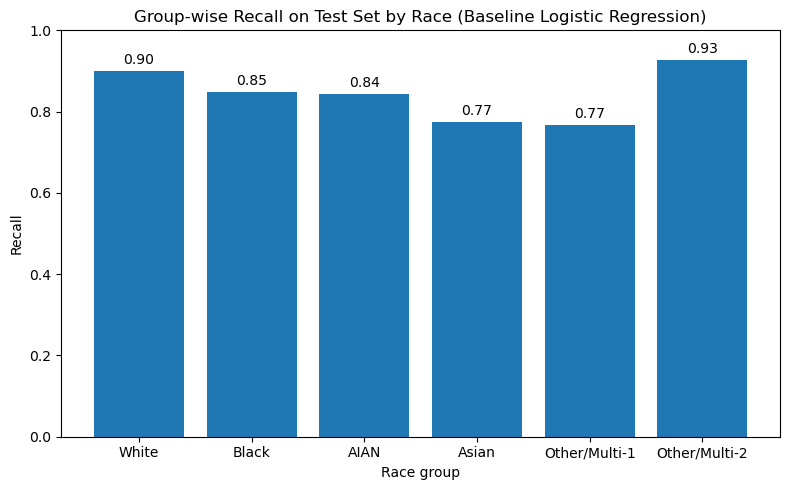

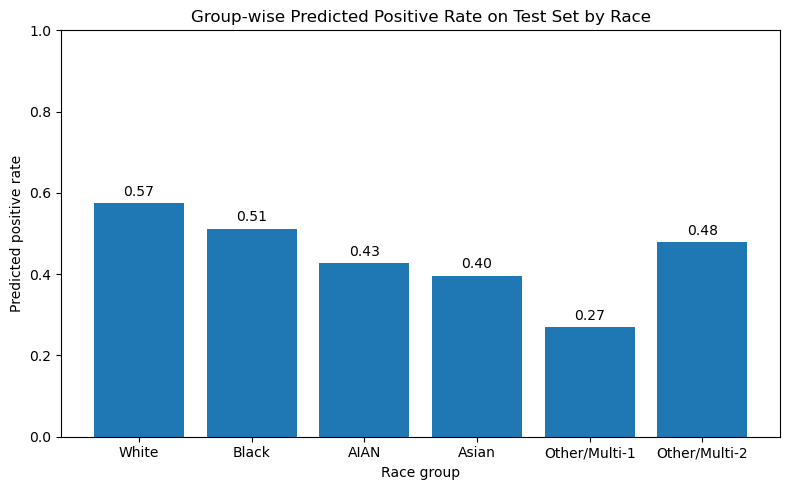

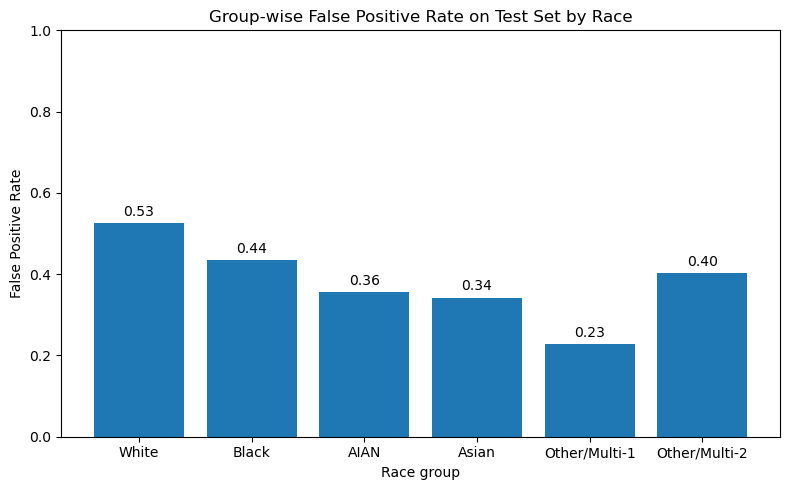

In [13]:
import matplotlib.pyplot as plt

race_labels = {
    100: "White",
    200: "Black",
    300: "AIAN",
    400: "Asian",
    510: "Other/Multi-1",
    542: "Other/Multi-2"
}

plot_df = group_metrics_df.copy()
plot_df["race_label"] = plot_df["RACENEW"].map(race_labels)

# Plot 1: Recall
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_label"], plot_df["recall"])
plt.xlabel("Race group")
plt.ylabel("Recall")
plt.title("Group-wise Recall on Test Set by Race (Baseline Logistic Regression)")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["recall"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Plot 2: Predicted positive rate
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_label"], plot_df["positive_rate_pred"])
plt.xlabel("Race group")
plt.ylabel("Predicted positive rate")
plt.title("Group-wise Predicted Positive Rate on Test Set by Race")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["positive_rate_pred"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

 # Plot 3: False Positive Rate
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_label"], plot_df["fpr"])
plt.xlabel("Race group")
plt.ylabel("False Positive Rate")
plt.title("Group-wise False Positive Rate on Test Set by Race")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["fpr"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [14]:
output_dir = Path(r"E:\Jupyter Notebook file\531\Project")

pd.DataFrame([overall_metrics]).to_csv(
    output_dir / "baseline_logreg_overall_metrics.csv",
    index=False
)

group_metrics_df.to_csv(
    output_dir / "baseline_logreg_group_metrics.csv",
    index=False
)

print("Saved:")
print("- baseline_logreg_overall_metrics.csv")
print("- baseline_logreg_group_metrics.csv")

Saved:
- baseline_logreg_overall_metrics.csv
- baseline_logreg_group_metrics.csv


## Logistic regression without class_weight

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

categorical_transformer_no_weight = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_no_weight = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer_no_weight, model_features)
    ]
)

log_reg_no_weight = Pipeline(steps=[
    ("preprocessor", preprocessor_no_weight),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

log_reg_no_weight.fit(X_train, y_train)

y_pred_no_weight = log_reg_no_weight.predict(X_test)
y_prob_no_weight = log_reg_no_weight.predict_proba(X_test)[:, 1]

print("Unweighted logistic regression fitted successfully.")

Unweighted logistic regression fitted successfully.


In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, balanced_accuracy_score
)

overall_metrics_no_weight = {
    "accuracy": accuracy_score(y_test, y_pred_no_weight),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_no_weight),
    "precision": precision_score(y_test, y_pred_no_weight, zero_division=0),
    "recall": recall_score(y_test, y_pred_no_weight, zero_division=0),
    "f1": f1_score(y_test, y_pred_no_weight, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_no_weight)
}

print("Overall metrics (no class_weight):")
for k, v in overall_metrics_no_weight.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_no_weight))

print("\nClassification report:")
print(classification_report(y_test, y_pred_no_weight, zero_division=0))

Overall metrics (no class_weight):
accuracy: 0.8642
balanced_accuracy: 0.5000
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.7442

Confusion matrix:
[[29471     2]
 [ 4630     0]]

Classification report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93     29473
           1       0.00      0.00      0.00      4630

    accuracy                           0.86     34103
   macro avg       0.43      0.50      0.46     34103
weighted avg       0.75      0.86      0.80     34103



In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score
from IPython.display import display

group_results_no_weight = []

test_results_no_weight = X_test.copy()
test_results_no_weight["y_true"] = y_test.values
test_results_no_weight["y_pred"] = y_pred_no_weight
test_results_no_weight["y_prob"] = y_prob_no_weight
test_results_no_weight[protected_col] = protected_test.values

for grp in sorted(test_results_no_weight[protected_col].unique()):
    subset = test_results_no_weight[test_results_no_weight[protected_col] == grp].copy()

    tn, fp, fn, tp = confusion_matrix(
        subset["y_true"], subset["y_pred"], labels=[0, 1]
    ).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    group_results_no_weight.append({
        "RACENEW": grp,
        "n_samples": len(subset),
        "positive_rate_true": subset["y_true"].mean(),
        "positive_rate_pred": subset["y_pred"].mean(),
        "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
        "precision": precision_score(subset["y_true"], subset["y_pred"], zero_division=0),
        "recall_tpr": tpr,
        "fpr": fpr,
        "tnr": tnr,
        "fnr": fnr,
        "f1": f1_score(subset["y_true"], subset["y_pred"], zero_division=0)
    })

group_metrics_no_weight_df = (
    pd.DataFrame(group_results_no_weight)
    .sort_values("RACENEW")
    .reset_index(drop=True)
)

display(group_metrics_no_weight_df.round(6))

,RACENEW,n_samples,positive_rate_true,positive_rate_pred,accuracy,precision,recall_tpr,fpr,tnr,fnr,f1
0,100,26557,0.130662,0.000038,0.869300,0.0,0.0,0.000043,0.999957,1.0,0.0
1,200,3843,0.186313,0.000260,0.813427,0.0,0.0,0.000320,0.999680,1.0,0.0
2,300,348,0.146552,0.000000,0.853448,0.0,0.0,0.000000,1.000000,1.0,0.0
3,400,2226,0.125337,0.000000,0.874663,0.0,0.0,0.000000,1.000000,1.0,0.0
4,510,764,0.078534,0.000000,0.921466,0.0,0.0,0.000000,1.000000,1.0,0.0
5,542,365,0.147945,0.000000,0.852055,0.0,0.0,0.000000,1.000000,1.0,0.0


In [18]:
comparison_df = pd.DataFrame([
    {"model": "logreg_balanced", **overall_metrics},
    {"model": "logreg_unweighted", **overall_metrics_no_weight}
]).round(4)

display(comparison_df)

,model,accuracy,precision,recall,f1,roc_auc,balanced_accuracy
0,logreg_balanced,0.5571,0.2192,0.8832,0.3513,0.7443,NaN
1,logreg_unweighted,0.8642,0.0000,0.0000,0.0000,0.7442,0.5


In [19]:
output_dir = Path(r"E:\Jupyter Notebook file\531\Project")

pd.DataFrame([overall_metrics_no_weight]).to_csv(
    output_dir / "logreg_no_weight_overall_metrics.csv",
    index=False
)

group_metrics_no_weight_df.to_csv(
    output_dir / "logreg_no_weight_group_metrics.csv",
    index=False
)

comparison_df.to_csv(
    output_dir / "logreg_weight_comparison.csv",
    index=False
)

print("Saved:")
print("- logreg_no_weight_overall_metrics.csv")
print("- logreg_no_weight_group_metrics.csv")
print("- logreg_weight_comparison.csv")

Saved:
- logreg_no_weight_overall_metrics.csv
- logreg_no_weight_group_metrics.csv
- logreg_weight_comparison.csv


## Model Comparison and Fairness Analysis

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, balanced_accuracy_score
)

categorical_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer_rf, model_features)
    ]
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

overall_metrics_rf = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "f1": f1_score(y_test, y_pred_rf, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_rf)
}

print("Overall metrics (Random Forest):")
for k, v in overall_metrics_rf.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Overall metrics (Random Forest):
accuracy: 0.5647
balanced_accuracy: 0.6840
precision: 0.2173
recall: 0.8477
f1: 0.3459
roc_auc: 0.7279

Confusion matrix:
[[15333 14140]
 [  705  3925]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.52      0.67     29473
           1       0.22      0.85      0.35      4630

    accuracy                           0.56     34103
   macro avg       0.59      0.68      0.51     34103
weighted avg       0.86      0.56      0.63     34103



In [21]:
comparison_df_all = pd.DataFrame([
    {"model": "logreg_balanced", **overall_metrics},
    {"model": "logreg_unweighted", **overall_metrics_no_weight},
    {"model": "random_forest_balanced", **overall_metrics_rf}
]).round(4)

display(comparison_df_all)

,model,accuracy,precision,recall,f1,roc_auc,balanced_accuracy
0,logreg_balanced,0.5571,0.2192,0.8832,0.3513,0.7443,NaN
1,logreg_unweighted,0.8642,0.0000,0.0000,0.0000,0.7442,0.500
2,random_forest_balanced,0.5647,0.2173,0.8477,0.3459,0.7279,0.684


In [22]:
def build_group_metrics_df(X_test, y_test, y_pred, y_prob, protected_test, protected_col="RACENEW"):
    test_results = X_test.copy()
    test_results["y_true"] = y_test.values
    test_results["y_pred"] = y_pred
    test_results["y_prob"] = y_prob
    test_results[protected_col] = protected_test.values

    rows = []

    for grp in sorted(test_results[protected_col].unique()):
        subset = test_results[test_results[protected_col] == grp].copy()

        tn, fp, fn, tp = confusion_matrix(
            subset["y_true"], subset["y_pred"], labels=[0, 1]
        ).ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        rows.append({
            "RACENEW": grp,
            "n_samples": len(subset),
            "positive_rate_true": subset["y_true"].mean(),
            "predicted_positive_rate": subset["y_pred"].mean(),
            "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
            "precision": precision_score(subset["y_true"], subset["y_pred"], zero_division=0),
            "recall_tpr": tpr,
            "fpr": fpr,
            "tnr": tnr,
            "fnr": fnr,
            "f1": f1_score(subset["y_true"], subset["y_pred"], zero_division=0)
        })

    return pd.DataFrame(rows).sort_values("RACENEW").reset_index(drop=True)

# Balanced logistic regression
group_metrics_logreg_df = build_group_metrics_df(
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    protected_test=protected_test,
    protected_col="RACENEW"
)

# Random forest
group_metrics_rf_df = build_group_metrics_df(
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred_rf,
    y_prob=y_prob_rf,
    protected_test=protected_test,
    protected_col="RACENEW"
)

print("Balanced Logistic Regression:")
display(group_metrics_logreg_df.round(6))

print("Random Forest:")
display(group_metrics_rf_df.round(6))

Balanced Logistic Regression:


,RACENEW,n_samples,positive_rate_true,predicted_positive_rate,accuracy,precision,recall_tpr,fpr,tnr,fnr,f1
0,100,26557,0.130662,0.574914,0.529841,0.204742,0.900865,0.525924,0.474076,0.099135,0.333654
1,200,3843,0.186313,0.512360,0.617747,0.308786,0.849162,0.435241,0.564759,0.150838,0.452886
2,300,348,0.146552,0.428161,0.672414,0.288591,0.843137,0.356902,0.643098,0.156863,0.430000
3,400,2226,0.125337,0.396676,0.672058,0.244621,0.774194,0.342578,0.657422,0.225806,0.371773
4,510,764,0.078534,0.270942,0.770942,0.222222,0.766667,0.228693,0.771307,0.233333,0.344569
5,542,365,0.147945,0.479452,0.646575,0.285714,0.925926,0.401929,0.598071,0.074074,0.436681


Random Forest:


,RACENEW,n_samples,positive_rate_true,predicted_positive_rate,accuracy,precision,recall_tpr,fpr,tnr,fnr,f1
0,100,26557,0.130662,0.560003,0.537222,0.203470,0.872046,0.513103,0.486897,0.127954,0.329953
1,200,3843,0.186313,0.491803,0.617486,0.300529,0.793296,0.422769,0.577231,0.206704,0.435917
2,300,348,0.146552,0.408046,0.686782,0.295775,0.823529,0.336700,0.663300,0.176471,0.435233
3,400,2226,0.125337,0.356694,0.698562,0.253149,0.720430,0.304571,0.695429,0.279570,0.374651
4,510,764,0.078534,0.253927,0.769634,0.201031,0.650000,0.220170,0.779830,0.350000,0.307087
5,542,365,0.147945,0.473973,0.646575,0.283237,0.907407,0.398714,0.601286,0.092593,0.431718


In [23]:
fairness_compare_df = pd.concat([
    group_metrics_logreg_df.assign(model="logreg_balanced"),
    group_metrics_rf_df.assign(model="random_forest_balanced")
], ignore_index=True)

fairness_compare_df = fairness_compare_df[
    [
        "model", "RACENEW", "n_samples",
        "recall_tpr", "fnr", "fpr", "tnr",
        "predicted_positive_rate"
    ]
].sort_values(["RACENEW", "model"]).reset_index(drop=True)

display(fairness_compare_df.round(6))

,model,RACENEW,n_samples,recall_tpr,fnr,fpr,tnr,predicted_positive_rate
0,logreg_balanced,100,26557,0.900865,0.099135,0.525924,0.474076,0.574914
1,random_forest_balanced,100,26557,0.872046,0.127954,0.513103,0.486897,0.560003
2,logreg_balanced,200,3843,0.849162,0.150838,0.435241,0.564759,0.512360
3,random_forest_balanced,200,3843,0.793296,0.206704,0.422769,0.577231,0.491803
4,logreg_balanced,300,348,0.843137,0.156863,0.356902,0.643098,0.428161
5,random_forest_balanced,300,348,0.823529,0.176471,0.336700,0.663300,0.408046
6,logreg_balanced,400,2226,0.774194,0.225806,0.342578,0.657422,0.396676
7,random_forest_balanced,400,2226,0.720430,0.279570,0.304571,0.695429,0.356694
8,logreg_balanced,510,764,0.766667,0.233333,0.228693,0.771307,0.270942
9,random_forest_balanced,510,764,0.650000,0.350000,0.220170,0.779830,0.253927


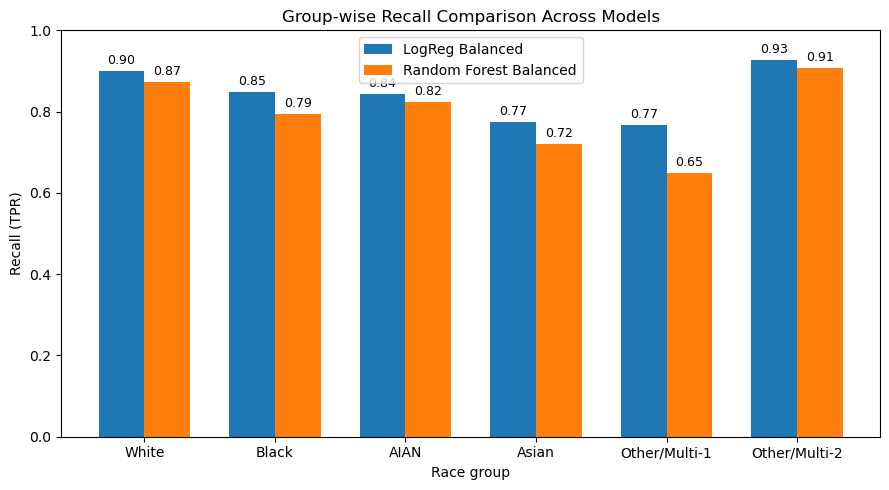

In [24]:
race_labels = {
    100: "White",
    200: "Black",
    300: "AIAN",
    400: "Asian",
    510: "Other/Multi-1",
    542: "Other/Multi-2"
}

plot_logreg = group_metrics_logreg_df.copy()
plot_rf = group_metrics_rf_df.copy()

plot_logreg["race_label"] = plot_logreg["RACENEW"].map(race_labels)
plot_rf["race_label"] = plot_rf["RACENEW"].map(race_labels)

groups = plot_logreg["race_label"].tolist()
x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, plot_logreg["recall_tpr"], width, label="LogReg Balanced")
bars2 = plt.bar(x + width/2, plot_rf["recall_tpr"], width, label="Random Forest Balanced")

plt.xticks(x, groups)
plt.xlabel("Race group")
plt.ylabel("Recall (TPR)")
plt.title("Group-wise Recall Comparison Across Models")
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

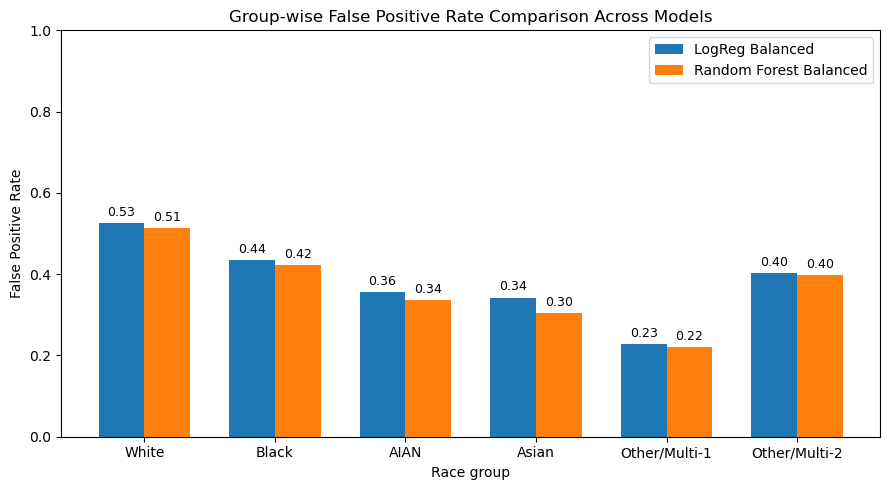

In [25]:
plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, plot_logreg["fpr"], width, label="LogReg Balanced")
bars2 = plt.bar(x + width/2, plot_rf["fpr"], width, label="Random Forest Balanced")

plt.xticks(x, groups)
plt.xlabel("Race group")
plt.ylabel("False Positive Rate")
plt.title("Group-wise False Positive Rate Comparison Across Models")
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

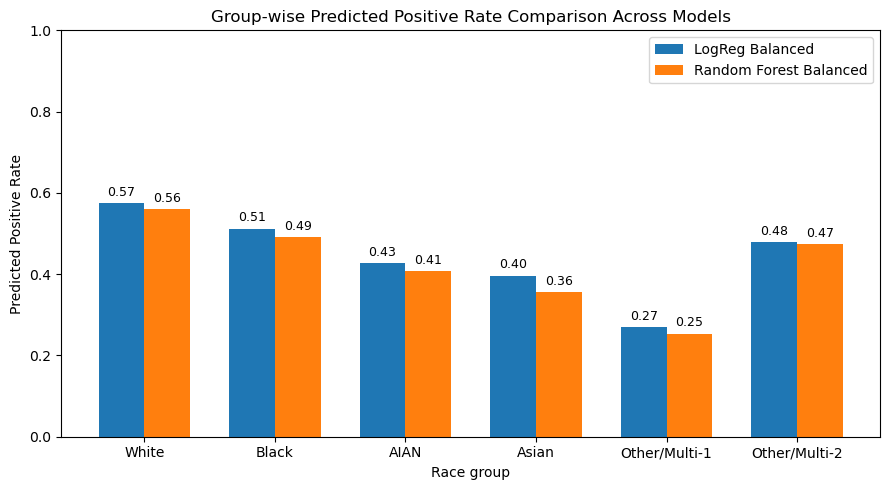

In [26]:
plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, plot_logreg["predicted_positive_rate"], width, label="LogReg Balanced")
bars2 = plt.bar(x + width/2, plot_rf["predicted_positive_rate"], width, label="Random Forest Balanced")

plt.xticks(x, groups)
plt.xlabel("Race group")
plt.ylabel("Predicted Positive Rate")
plt.title("Group-wise Predicted Positive Rate Comparison Across Models")
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [27]:
output_dir = Path(r"E:\Jupyter Notebook file\531\Project")

comparison_df_all.to_csv(
    output_dir / "model_comparison_overall_metrics.csv",
    index=False
)

group_metrics_logreg_df.to_csv(
    output_dir / "group_metrics_logreg_balanced.csv",
    index=False
)

group_metrics_rf_df.to_csv(
    output_dir / "group_metrics_random_forest_balanced.csv",
    index=False
)

fairness_compare_df.to_csv(
    output_dir / "fairness_metrics_across_models.csv",
    index=False
)

print("Saved:")
print("- model_comparison_overall_metrics.csv")
print("- group_metrics_logreg_balanced.csv")
print("- group_metrics_random_forest_balanced.csv")
print("- fairness_metrics_across_models.csv")

Saved:
- model_comparison_overall_metrics.csv
- group_metrics_logreg_balanced.csv
- group_metrics_random_forest_balanced.csv
- fairness_metrics_across_models.csv
